## Import libraries

This cell imports the Python packages used throughout the analysis:

- **pandas** for data manipulation and analysis
- **Matplotlib** for data visualization

It also configures pandas to display all columns when showing DataFrames.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_columns",None)

## Load the CKD dataset

This cell downloads the Chronic Kidney Disease (CKD) dataset from the UCI Machine Learning Repository and loads it into a pandas DataFrame.

The shape of the dataset is displayed so we can see how many rows and columns are available, and the first few records are shown to verify that the data loaded correctly.

In [2]:
url="https://archive.ics.uci.edu/static/public/336/data.csv"
df=pd.read_csv(url)
print(df.shape)
df.head()

(400, 25)


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


## Prepare and clean the data

This cell creates the modified dataset required for the assignment.

The following transformations are performed:

1. Select only the required columns.
2. Rename columns using descriptive names.
3. Convert numerical columns to proper numeric data types.
4. Convert hemoglobin values from g/dl to g/l.
5. Recode the class variable:
   - `a` = affected
   - `c` = control
6. Remove rows containing three or more missing values.

The number of remaining rows is then displayed.

In [3]:
selected_columns={
"age":"age","bp":"blood pressure","sg":"specific gravity","al":"albumin","su":"sugar","bgr":"blood glucose random","bu":"blood urea","sod":"sodium","pot":"potassium","hemo":"hemoglobin","pcv":"packed cell volume","wbcc":"white blood cell count","rbcc":"red blood cell count","class":"class"}

ckd=df[list(selected_columns.keys())].rename(columns=selected_columns)
for c in ckd.columns[:-1]:
    ckd[c]=pd.to_numeric(ckd[c],errors="coerce")
ckd["hemoglobin"]=ckd["hemoglobin"]*10
ckd["class"]=(ckd["class"].astype(str).str.strip().replace({"ckd":"a","ckd\t":"a","notckd":"c"}))
ckd=ckd[ckd.isna().sum(axis=1)<3].reset_index(drop=True)
print("Rows remaining:",len(ckd))
ckd.head()

Rows remaining: 265


,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count,class
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,NaN,NaN,154.0,44.0,7800.0,5.2,a
1,48.0,70.0,1.005,4.0,0.0,117.0,56.0,111.0,2.5,112.0,32.0,6700.0,3.9,a
2,51.0,80.0,1.010,2.0,0.0,106.0,26.0,NaN,NaN,116.0,35.0,7300.0,4.6,a
3,60.0,90.0,1.015,3.0,0.0,74.0,25.0,142.0,3.2,122.0,39.0,7800.0,4.4,a
4,68.0,70.0,1.010,0.0,0.0,100.0,54.0,104.0,4.0,124.0,36.0,NaN,NaN,a


## Split the data into affected and control groups

This cell separates the cleaned dataset into two independent DataFrames:

- **affected_df** containing individuals with CKD (`a`)
- **control_df** containing healthy controls (`c`)

The number of rows in each group is reported and both DataFrames are displayed.

In [4]:
affected_df=ckd[ckd["class"]=="a"]
control_df=ckd[ckd["class"]=="c"]
print("Affected rows:",len(affected_df))
print("Control rows:",len(control_df))
affected_df.head(), control_df.head()

Affected rows: 126
Control rows: 139


(    age  blood pressure  specific gravity  albumin  sugar  \
 0  48.0            80.0             1.020      1.0    0.0   
 1  48.0            70.0             1.005      4.0    0.0   
 2  51.0            80.0             1.010      2.0    0.0   
 3  60.0            90.0             1.015      3.0    0.0   
 4  68.0            70.0             1.010      0.0    0.0   
 
    blood glucose random  blood urea  sodium  potassium  hemoglobin  \
 0                 121.0        36.0     NaN        NaN       154.0   
 1                 117.0        56.0   111.0        2.5       112.0   
 2                 106.0        26.0     NaN        NaN       116.0   
 3                  74.0        25.0   142.0        3.2       122.0   
 4                 100.0        54.0   104.0        4.0       124.0   
 
    packed cell volume  white blood cell count  red blood cell count class  
 0                44.0                  7800.0                   5.2     a  
 1                32.0                  6700

## Calculate descriptive statistics

This cell computes summary statistics for every numerical variable in both groups.

The output includes:

- Count
- Mean
- Standard deviation
- Minimum
- Quartiles (25%, 50%, 75%)
- Maximum

These statistics provide a general understanding of the data distributions.

In [5]:
display(affected_df.describe())
display(control_df.describe())

,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count
count,123.000000,125.000000,125.000000,126.000000,126.000000,120.000000,125.000000,108.000000,108.000000,125.000000,125.000000,113.000000,108.000000
mean,57.081301,80.720000,1.013560,1.849206,0.809524,181.200000,80.420000,133.731481,4.751852,106.432000,32.440000,9450.442478,3.976852
std,14.465104,15.769305,0.004527,1.437038,1.366539,93.549394,60.501346,7.666661,4.203592,21.896507,7.150908,3720.458015,0.844510
min,6.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,104.000000,2.500000,31.000000,9.000000,2600.000000,2.100000
25%,49.500000,70.000000,1.010000,0.250000,0.000000,107.000000,37.000000,131.750000,3.800000,95.000000,29.000000,7100.000000,3.400000
50%,60.000000,80.000000,1.015000,2.000000,0.000000,158.000000,60.000000,136.000000,4.200000,108.000000,33.000000,9200.000000,3.900000
75%,65.000000,90.000000,1.015000,3.000000,1.000000,241.250000,107.000000,139.000000,4.900000,120.000000,37.000000,11000.000000,4.400000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,322.000000,145.000000,47.000000,161.000000,52.000000,26400.000000,8.000000


,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count
count,139.000000,137.000000,139.000000,139.0,139.0,135.000000,135.000000,136.000000,136.000000,137.000000,138.000000,136.000000,136.000000
mean,46.568345,71.313869,1.022482,0.0,0.0,107.385185,32.874074,141.735294,4.335294,151.883212,46.246377,7708.088235,5.380882
std,15.903719,8.559267,0.002509,0.0,0.0,18.747730,11.482257,4.792332,0.596351,12.845270,4.107695,1815.164727,0.592986
min,12.000000,60.000000,1.020000,0.0,0.0,70.000000,10.000000,135.000000,3.300000,130.000000,40.000000,4300.000000,4.500000
25%,34.000000,60.000000,1.020000,0.0,0.0,93.000000,23.500000,138.000000,3.700000,141.000000,43.000000,6300.000000,4.900000
50%,46.000000,70.000000,1.020000,0.0,0.0,107.000000,33.000000,141.000000,4.500000,150.000000,46.000000,7450.000000,5.300000
75%,58.000000,80.000000,1.025000,0.0,0.0,123.500000,44.000000,146.000000,4.900000,162.000000,50.000000,9225.000000,5.900000
max,80.000000,80.000000,1.025000,0.0,0.0,140.000000,50.000000,150.000000,5.000000,178.000000,54.000000,11000.000000,6.500000


## Visualize variable distributions

This cell creates histograms for every numerical variable in both groups.

Histograms help identify:

- Distribution shapes
- Skewness
- Potential outliers
- Differences between affected and control individuals

The graphs should be examined before performing further analysis.

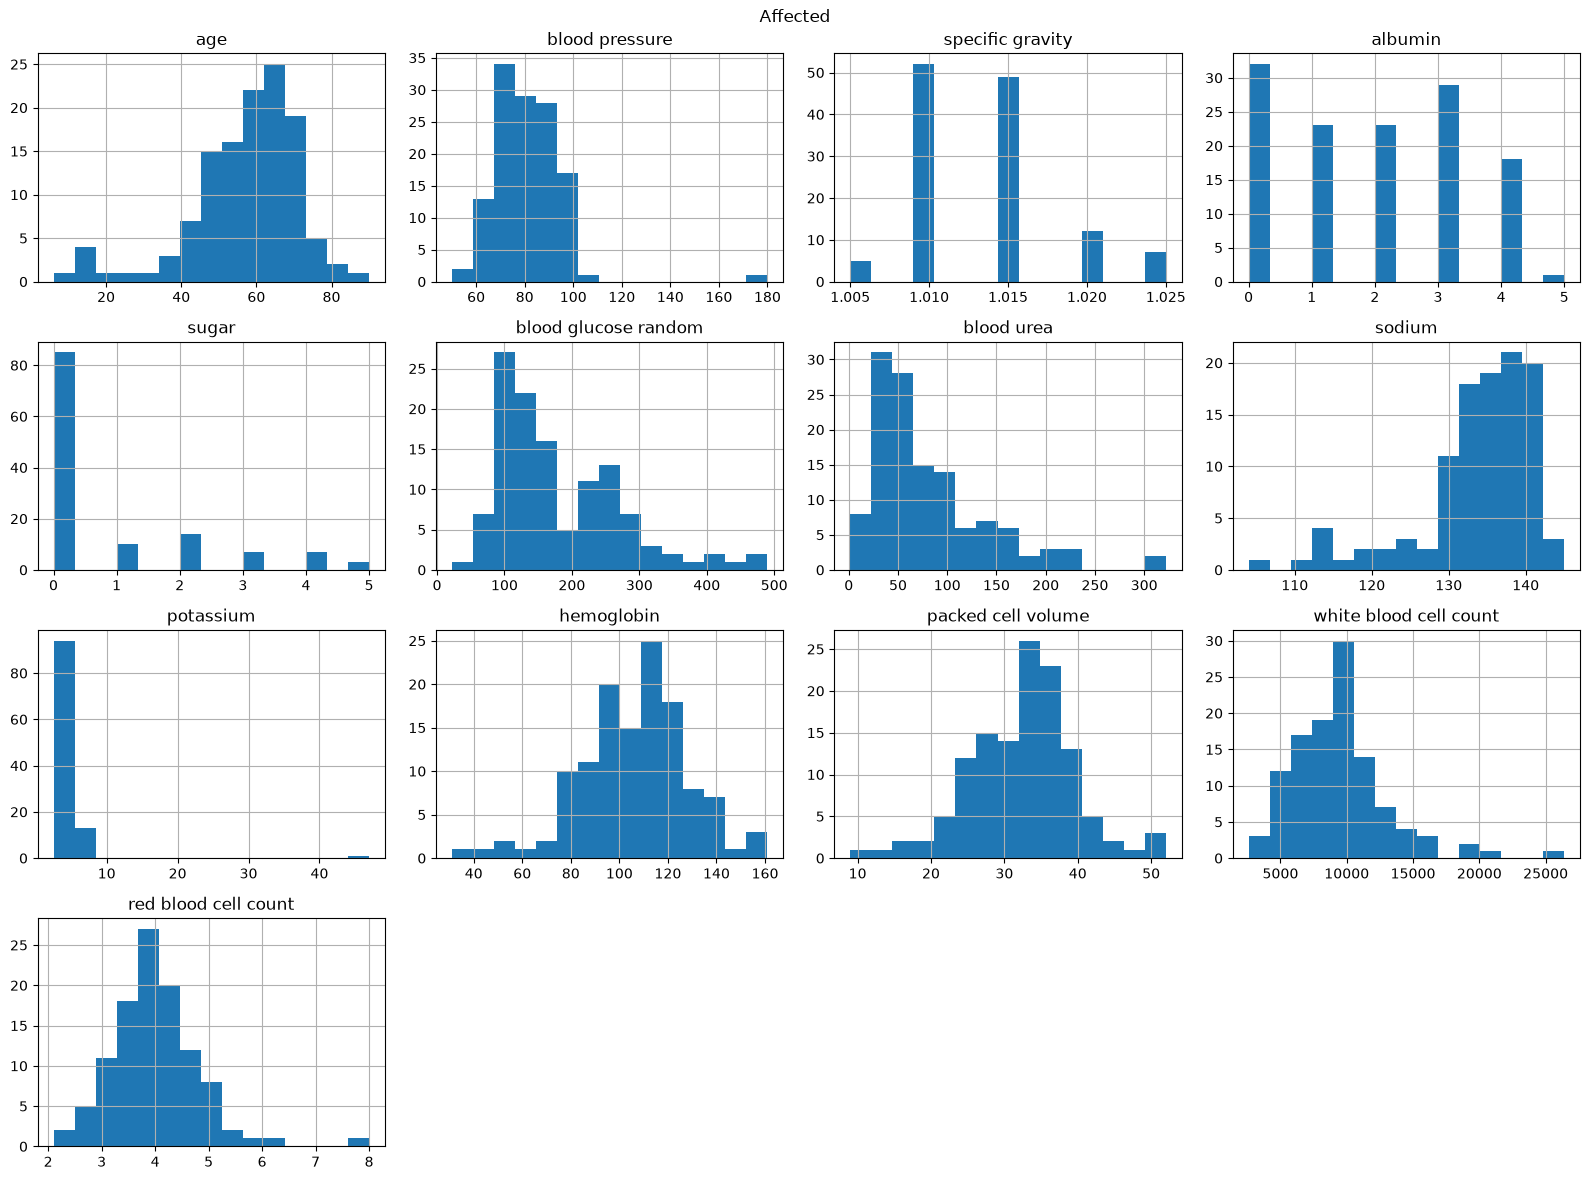

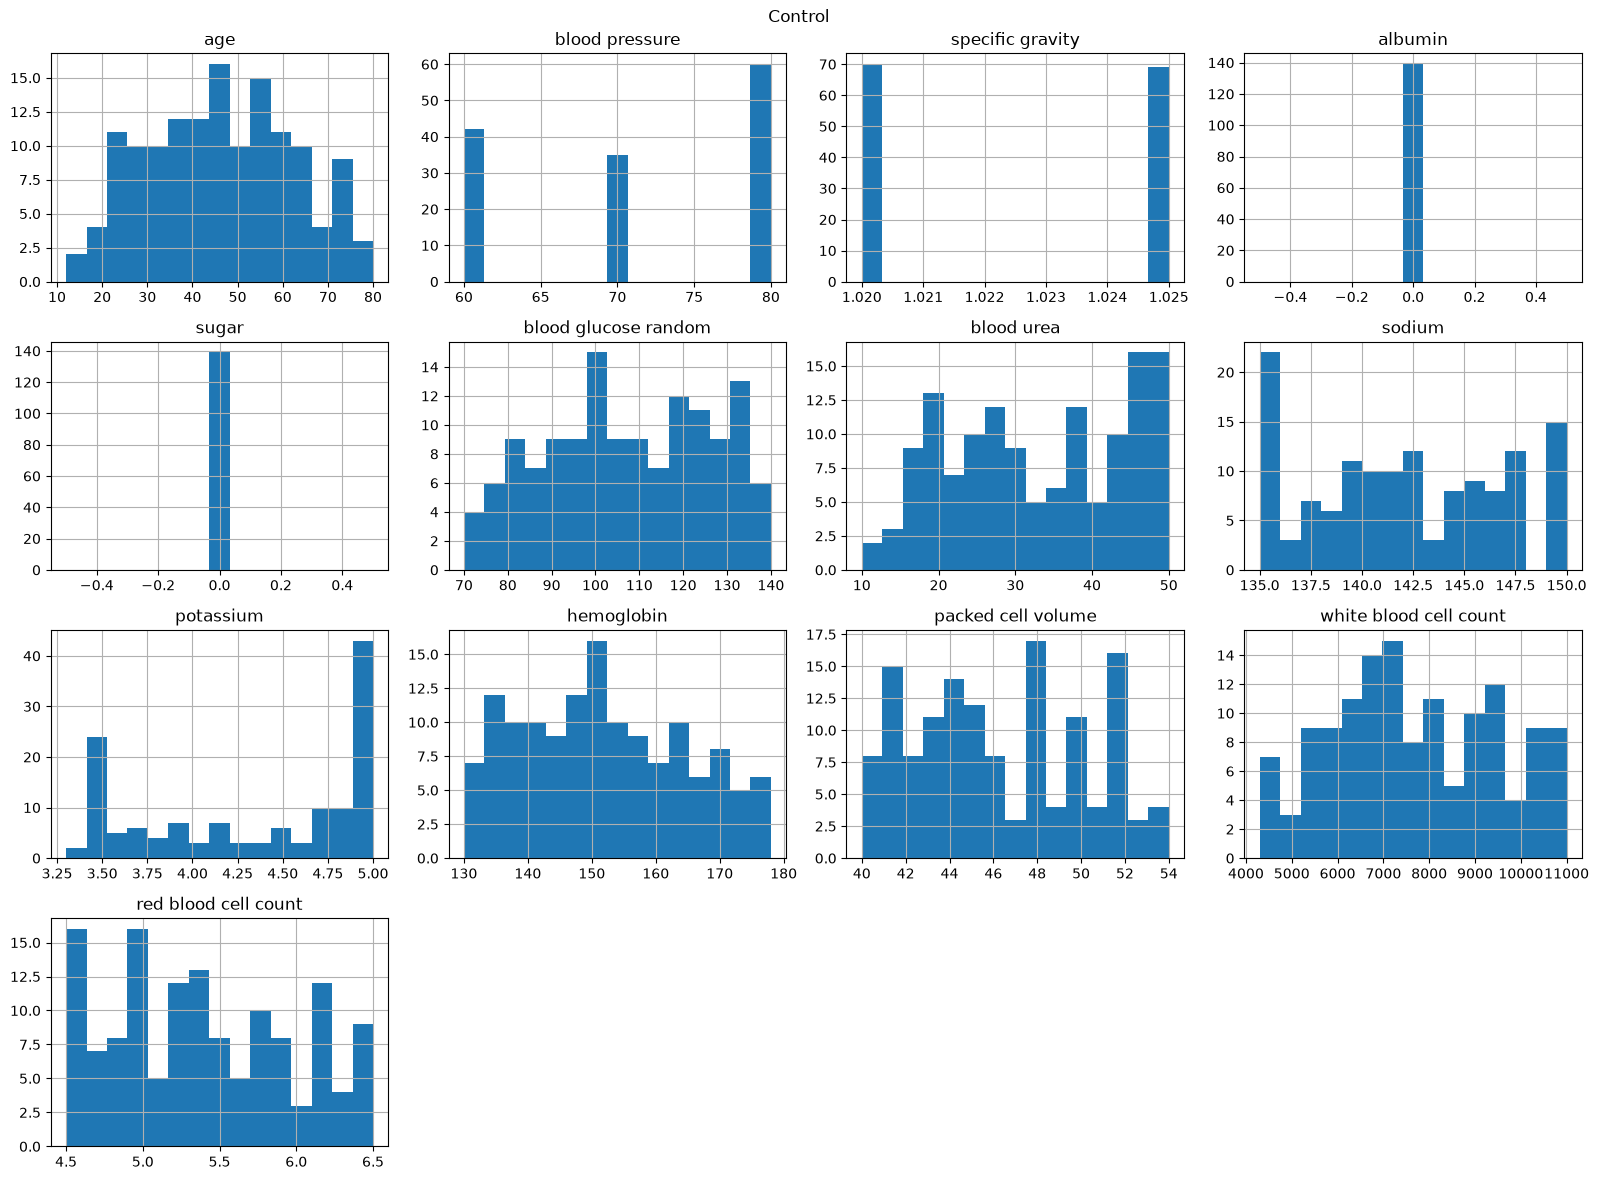

In [6]:
def plot_histograms(frame,title):
    cols=[c for c in frame.columns if c!="class"]
    frame[cols].hist(figsize=(16,12),bins=15)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_histograms(affected_df,"Affected")
plot_histograms(control_df,"Control")

There are some differences to be found between the affected and control group's histograms.

Overall, the affected group's statistics are more skewed, and the control group seems to be more evenly distributed and concentrated within a narrower range. The affected group shows longer tails in several variables.

Some clear patterns can be found in the affected group, such as clear peaks in blood glucose, blood urea, sodium, hemoglobin and packed cell volume. White and red blood cell counts seem to cluster or spike in specific numbers in the affected group, in contrast to the control group where the distribution is again more even.

Some outliers can be found by looking at the histograms. Examples in the affected group include suspicious values in potassium, blood pressure, blood urea and cell counts. These outliers could possibly be removed, by defining reasonable minimums and maximums for the data values. However this must be done carefully, to not automatically remove clinically plausible values and thus skewing the data.

In conclusion, the histograms generally suggest that the affected group is more skewed and extreme, while the control group is more even and regular.

## Correlation analysis

This cell calculates Pearson correlation coefficients between all numerical variables.

The results are presented as:

1. A correlation matrix containing the numerical correlation values.
2. A heatmap visualizing the strength and direction of relationships.

Interpretation guidelines:

- Values close to **+1** indicate a strong positive relationship.
- Values close to **−1** indicate a strong negative relationship.
- Values near **0** indicate little or no linear relationship.

The correlation patterns can then be compared between affected and control groups.

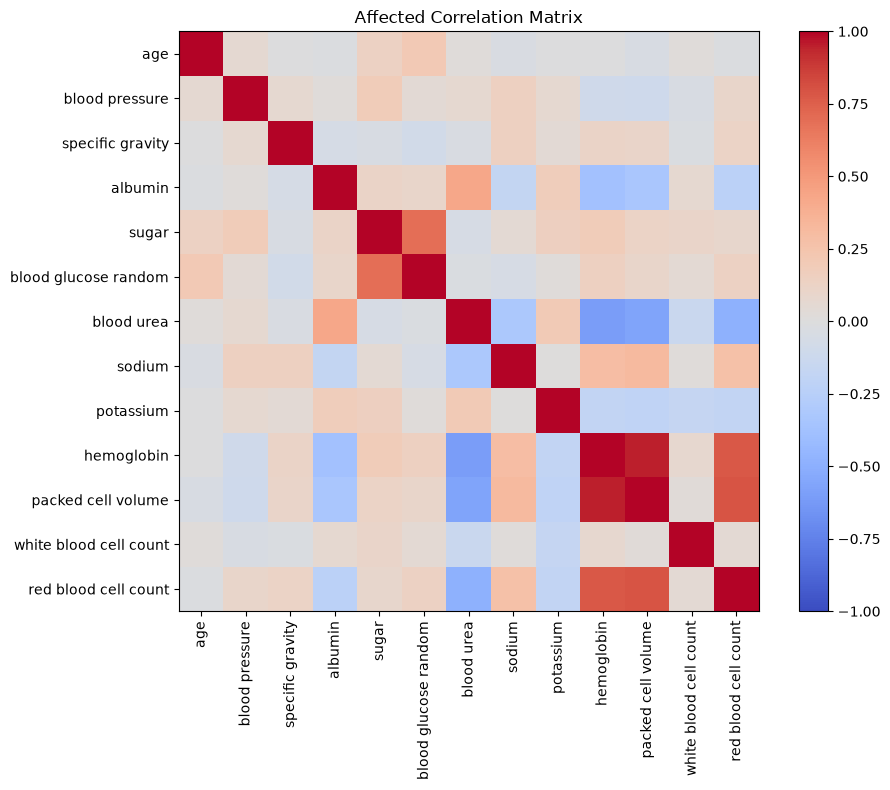

,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count
age,1.000000,0.061731,-0.004869,-0.016726,0.138945,0.205133,0.022593,-0.033951,-0.007490,-0.006174,-0.044467,0.015848,-0.016616
blood pressure,0.061731,1.000000,0.066651,0.022210,0.181615,0.041162,0.064547,0.148208,0.068721,-0.097107,-0.104029,-0.040061,0.095163
specific gravity,-0.004869,0.066651,1.000000,-0.061509,-0.044993,-0.083967,-0.037977,0.143235,0.046375,0.114042,0.106808,-0.026688,0.120779
albumin,-0.016726,0.022210,-0.061509,1.000000,0.115618,0.099096,0.426974,-0.179331,0.176842,-0.371257,-0.329337,0.067898,-0.231920
sugar,0.138945,0.181615,-0.044993,0.115618,1.000000,0.692159,-0.053597,0.052022,0.152143,0.184927,0.120275,0.103631,0.091519
blood glucose random,0.205133,0.041162,-0.083967,0.099096,0.692159,1.000000,-0.029130,-0.053968,0.019949,0.144666,0.097501,0.049505,0.140348
blood urea,0.022593,0.064547,-0.037977,0.426974,-0.053597,-0.029130,1.000000,-0.320019,0.197928,-0.608652,-0.568745,-0.135999,-0.487755
sodium,-0.033951,0.148208,0.143235,-0.179331,0.052022,-0.053968,-0.320019,1.000000,0.002814,0.295139,0.317933,0.019716,0.266934
potassium,-0.007490,0.068721,0.046375,0.176842,0.152143,0.019949,0.197928,0.002814,1.000000,-0.181083,-0.198267,-0.169084,-0.185432
hemoglobin,-0.006174,-0.097107,0.114042,-0.371257,0.184927,0.144666,-0.608652,0.295139,-0.181083,1.000000,0.951500,0.071613,0.779202


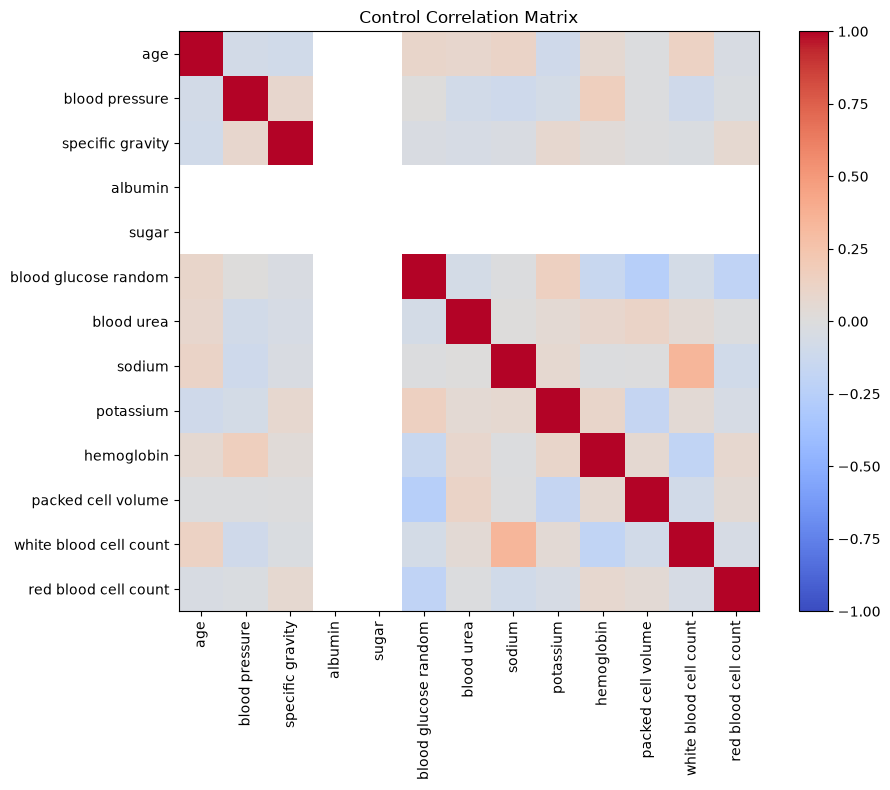

,age,blood pressure,specific gravity,albumin,sugar,blood glucose random,blood urea,sodium,potassium,hemoglobin,packed cell volume,white blood cell count,red blood cell count
age,1.000000,-0.071093,-0.092814,NaN,NaN,0.101408,0.078620,0.110581,-0.094361,0.056334,-0.009969,0.128762,-0.045118
blood pressure,-0.071093,1.000000,0.084470,NaN,NaN,0.004094,-0.084057,-0.107489,-0.064606,0.157748,-0.007854,-0.098981,-0.030603
specific gravity,-0.092814,0.084470,1.000000,NaN,NaN,-0.038416,-0.050116,-0.033880,0.074253,0.026303,-0.007082,-0.028054,0.067207
albumin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sugar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
blood glucose random,0.101408,0.004094,-0.038416,NaN,NaN,1.000000,-0.067850,-0.007900,0.146784,-0.147729,-0.257604,-0.069143,-0.196675
blood urea,0.078620,-0.084057,-0.050116,NaN,NaN,-0.067850,1.000000,0.005475,0.047313,0.085647,0.116931,0.041256,-0.010890
sodium,0.110581,-0.107489,-0.033880,NaN,NaN,-0.007900,0.005475,1.000000,0.065758,-0.011060,-0.001524,0.338373,-0.092615
potassium,-0.094361,-0.064606,0.074253,NaN,NaN,0.146784,0.047313,0.065758,1.000000,0.099223,-0.168690,0.041307,-0.052842
hemoglobin,0.056334,0.157748,0.026303,NaN,NaN,-0.147729,0.085647,-0.011060,0.099223,1.000000,0.057235,-0.191126,0.075912


In [7]:
def corr_plot(frame,title):
    corr=frame.drop(columns=["class"]).corr()
    plt.figure(figsize=(10,8))
    plt.imshow(corr,cmap="coolwarm",vmin=-1,vmax=1)
    plt.xticks(range(len(corr.columns)),corr.columns,rotation=90)
    plt.yticks(range(len(corr.columns)),corr.columns)
    plt.colorbar()
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return corr

display(corr_plot(affected_df,"Affected Correlation Matrix"))
display(corr_plot(control_df,"Control Correlation Matrix"))

The affected correlation matrix shows some clear relationships between variables. The clearest are positive correlations between hemoglobin and packed cell volume, hemoglobin and red blood cell count, and packed cell volume and red blood cell count. These variables are clearly closely related, showing a cluster of correlations. Negative correlations are found between blood urea and hemoglobin, and blood urea and packed cell volume.

In contrast, the control matrix seems to be closer to zero in most cases. There is a weak positive correlation between sodium and white blood cell count. Overall, relationships between variables seem to be weak.

The main findings are that the affected group has both clearer patterns and stronger correlation relationships in comparison to the control group. As seen before, the control group seems generally more homogenous. A broad cluster can be seen in the affected matrix: hemoglobin, packed cell volume and red blood cell count.